In [ ]:
## Import Packages


In [1]:
import pandas as pd
from nilearn.datasets import fetch_atlas_schaefer_2018
from neuromaps.parcellate import Parcellater
import warnings
from neuromaps.datasets import fetch_fslr, fetch_annotation
from neuromaps import datasets, images, nulls, resampling, stats, transforms, parcellate
from neuromaps.parcellate import Parcellater 
from neuromaps.resampling import resample_images
from neuromaps.images import dlabel_to_gifti
import neuromaps
import nibabel as nib
import os
import numpy as np
import mayavi
from PIL import Image
import hcp_utils as hcp
import nilearn.plotting as plotting
import warnings
from netneurotools.datasets import fetch_cammoun2012
from netneurotools import datasets as nntdata
#import abagen ## This is important for certification purposes 
warnings.filterwarnings('ignore')

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [ ]:
## Set Paths and Variables

In [2]:
# Paths
root="/Users/pecsok/Desktop/ImageData/PMACS_remote/data/cest"
preproc = root + "/preprocessed"
postproc = root + "/postprocessed"

# Variables
subjs = [folder for folder in os.listdir(preproc) if os.path.isdir(os.path.join(preproc, folder))]
atlasname = "Schaefer2018_1000Parcels_17Networks"  
mni_nifti = '/Users/pecsok/Downloads/mni_icbm152_nlin_asym_09a_nifti/mni_icbm152_nlin_asym_09a/mni_icbm152_t1_tal_nlin_asym_09a.nii'
schaefer_nifti = nib.load('/Users/pecsok/projects/Neuromaps/pecsok_pfns/neuromaps/data/test_masks/Schaefer2018_1000Parcels_17Networks_order_FSLMNI152_1mm.nii.gz')
schaefer_data = schaefer_nifti.get_fdata()


# Initialize the output DataFrame
columns = ['Subject'] + [str(i) for i in range(1, 1001)]
b1vals = pd.DataFrame(columns=columns)



In [4]:
# Parcellate and compile b1 maps
for id in subjs: 
    # Load subject files
    try:
        b1nifti = nib.load(os.path.join(preproc, id, f"{id}-B1MAP.nii"))
        masknifti = nib.load(os.path.join(preproc, id, f"{id}_cestmask.nii"))
        atlasnifti = nib.load(os.path.join(postproc, id, f"atlases/UNI/{id}-cest-{atlasname}.nii.gz"))
    except FileNotFoundError:
        print(f"Files missing for subject {id}")

    # Parcellate 
    parcellated = {}
    parcellater = Parcellater(atlasnifti, 'MNI152')
    parcellated[id] = parcellater.fit_transform(b1nifti, 'MNI152', True)
    print(parcellated[id].shape)
    
    # Get parcel labels
    atlas_data = atlasnifti.get_fdata()
    unique_labels = np.unique(atlas_data)
    unique_labels = unique_labels[unique_labels != 0]
    unique_labels = [str(int(label)) for label in unique_labels]

    # Make Subject DataFrame
    subj_df = pd.DataFrame(parcellated[id], columns=unique_labels)
    new_row = {'Subject': id} 
    for label in unique_labels:
        new_row[label] = subj_df[label].values[0]
    
    # Add new row to group DataFrame using pd.concat
    new_row_df = pd.DataFrame([new_row])
    b1vals = pd.concat([b1vals, new_row_df], ignore_index=True)


(1, 131)
(1, 109)
(1, 122)
Files missing for subject 20871_12235
(1, 122)
(1, 127)
(1, 123)
(1, 108)
(1, 112)
(1, 101)
(1, 118)
Files missing for subject 90877_10907
(1, 118)
(1, 126)
(1, 101)
Files missing for subject 130438_12326
(1, 101)
(1, 124)
(1, 125)
(1, 109)
Files missing for subject 87646_10754
(1, 109)
(1, 121)
(1, 117)
Files missing for subject 139272_10739
(1, 117)
(1, 125)
(1, 114)
Files missing for subject 88760_11846
(1, 114)
(1, 118)
(1, 100)
(1, 127)
(1, 113)
(1, 112)
(1, 110)
(1, 127)
(1, 117)
(1, 112)
(1, 90)
(1, 128)
(1, 126)
(1, 119)
(1, 116)
(1, 129)
(1, 103)
(1, 129)
(1, 125)
(1, 116)
(1, 112)
(1, 132)
(1, 117)
(1, 123)
(1, 120)
(1, 116)
(1, 127)
Files missing for subject 88608_10764
(1, 127)
(1, 114)
(1, 122)
(1, 118)
(1, 107)
(1, 113)
(1, 129)
(1, 103)
(1, 123)
(1, 131)
(1, 118)
(1, 123)
(1, 127)
(1, 107)
(1, 109)
(1, 113)
(1, 111)
(1, 127)
(1, 130)
(1, 129)
(1, 104)
(1, 127)
(1, 117)
Files missing for subject 87225_10933
(1, 117)
(1, 120)
(1, 117)
(1, 116)
(1

In [6]:
## Make nifti with average b1 Values
# Make b1 averages dataframe
b1vals_no_subject = b1vals.drop(columns=["Subject"])
b1averages = b1vals_no_subject.mean()
parcel_values = pd.DataFrame({'parcel_id': range(1, 1001), 'value': b1averages.values})
print(parcel_values)

# Create a copy of the Schaefer atlas array to modify
new_schaefer_data = np.zeros(schaefer_data.shape)

# Loop through each parcel and assign the corresponding value from your DataFrame
for i, row in parcel_values.iterrows():
    parcel_id = row['parcel_id']
    value = row['value']
    # Assign the value to all voxels belonging to the current parcel ID
    new_schaefer_data[schaefer_data == parcel_id] = value

# Create and save nifti
b1_nifti = nib.Nifti1Image(new_schaefer_data, affine=schaefer_nifti.affine, header=schaefer_nifti.header)
b1_nifti.to_filename('b1averages.nii.gz')

     parcel_id     value
0            1  0.616558
1            2       NaN
2            3  0.613734
3            4  0.525057
4            5       NaN
..         ...       ...
995        996       NaN
996        997       NaN
997        998       NaN
998        999       NaN
999       1000       NaN

[1000 rows x 2 columns]


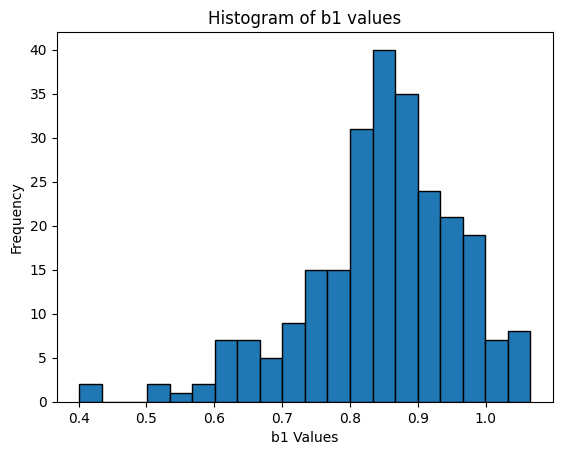

In [7]:
# Histogram of b1 values
import matplotlib.pyplot as plt

# Plot histogram for the specified column
parcel_values['value'].plot(kind='hist', bins=20, edgecolor='black')

# Add labels and title
plt.xlabel('b1 Values')
plt.ylabel('Frequency')
plt.title('Histogram of b1 values')

# Show the plot
plt.show()

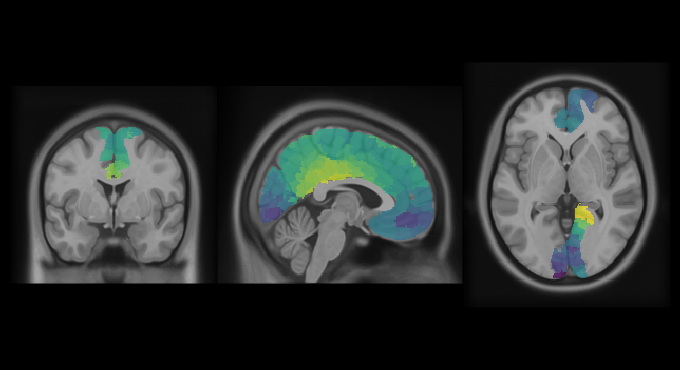

In [10]:
from nilearn.image import load_img
from matplotlib.colors import ListedColormap


mni_nifti = '/Users/pecsok/Downloads/mni_icbm152_nlin_asym_09a_nifti/mni_icbm152_nlin_asym_09a/mni_icbm152_t1_tal_nlin_asym_09a.nii'

mni_img = load_img(mni_nifti)

   
# Plotting:
# Set color scheme
#overlay_color = vonecon_palette[von_ec]
#custom_cmap = ListedColormap([overlay_color])
b1_display = plotting.plot_roi(
    b1_nifti,
    bg_img=mni_img,
    #title="Mask Overlay",
    display_mode="ortho",
    cut_coords=(3, 0, 0),
    cmap='viridis',
    draw_cross=False,
    annotate = False
)
b1_display.title = None  # Remove the title managed by nilearn
plt.gcf().suptitle("Mask Overlay", fontsize=16)  # Add a clean custom title

plotting.show()

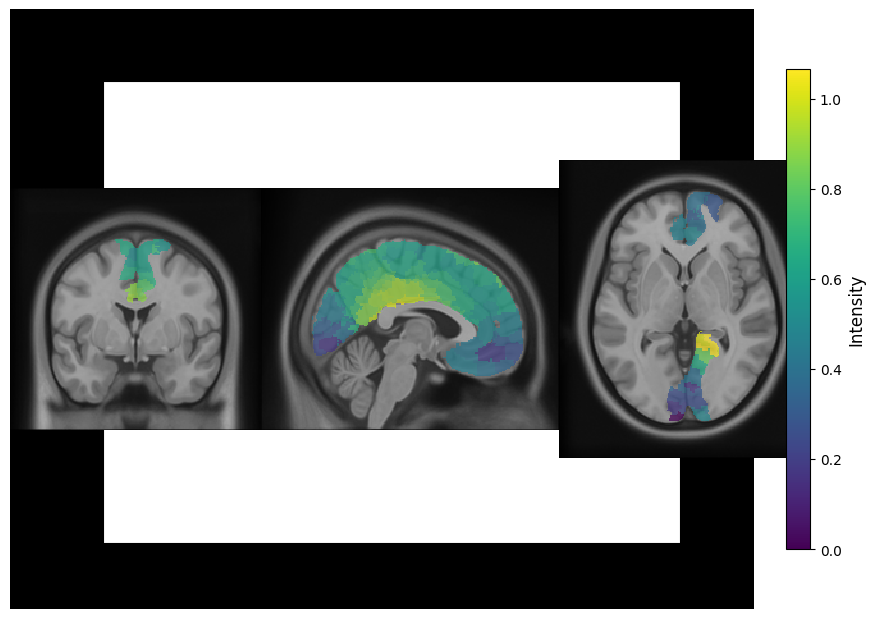

In [12]:
import matplotlib.pyplot as plt
from nilearn import plotting
import numpy as np

# Display the ROI with a custom plot using matplotlib
fig, ax = plt.subplots(figsize=(8, 6))

# Create the plot
b1_display = plotting.plot_roi(
    b1_nifti,
    bg_img=mni_img,
    display_mode="ortho",
    cut_coords=(3, 0, 0),
    cmap='viridis',
    draw_cross=False,
    annotate=False,
    figure=fig,
)

# Add a clean custom title
plt.gcf().suptitle("Mask Overlay", fontsize=16)

# Add a color bar using matplotlib
norm = plt.Normalize(vmin=np.nanmin(b1_nifti.get_fdata()), vmax=np.nanmax(b1_nifti.get_fdata()))
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=fig.axes, fraction=0.03, pad=0.04)
cbar.set_label("Intensity", fontsize=12)  # Label for the color bar

# Show the plot
plotting.show()
